In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

In [6]:
df_clean = pd.read_csv('../../dataset/clean/makanan_kemasan_clean.csv')
print(f"Shape dataset: {df_clean.shape}")
df_clean.head(10)

Shape dataset: (10953, 10)


,nama_makanan,kategori_makanan,jenis_kemasan,lokasi_penyimpanan,sudah_terbuka,hari_berakhir,hari_sejak_dibuka,sisa_hari,label,cara_simpan
0,Yogurt Plain,Produk Olahan Susu,Plastik,Pendingin,0,5,0,5,Segera,Simpan dalam kulkas pada suhu stabil 2-5°C unt...
1,Biskuit Marie,Produk Kering,Plastik,Suhu Ruang,0,31,0,31,Segar,"Simpan di tempat kering dan sejuk, hindarkan d..."
2,Nugget Udang,Produk Protein,Plastik,Unknown,0,101,0,101,Segar,Simpan di tempat yang bersih dan sesuai dengan...
3,Sarden Cabai,Produk Kaleng,Kaleng,Suhu Ruang,0,423,0,250,Segar,"Simpan di tempat kering dan sejuk, hindarkan d..."
4,Biskuit Crackers,Produk Kering,Plastik,Suhu Ruang,0,138,0,138,Segar,"Simpan di tempat kering dan sejuk, hindarkan d..."
5,Susu Uht Stroberi,Produk Olahan Susu,Karton,Pendingin,1,85,4,-3,Kadaluwarsa,"Setelah dibuka, tutup rapat dan segera simpan ..."
6,Sosis Frankfurter,Produk Protein,Plastik,Pendingin,0,42,0,42,Segar,Simpan dalam kulkas pada suhu stabil 2-5°C unt...
7,Sarden Cabai,Produk Kaleng,Kaleng,Suhu Ruang,1,398,7,-5,Kadaluwarsa,Jangan simpan di dalam kaleng yang sudah terbu...
8,Biskuit Mentega,Produk Kering,Kaleng,Suhu Ruang,0,35,0,35,Segar,"Simpan di tempat kering dan sejuk, hindarkan d..."
9,Susu Bubuk Coklat,Produk Olahan Susu,Karton,Suhu Ruang,1,500,12,6,Segera,"Setelah dibuka, tutup rapat dan segera simpan ..."


In [7]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10953 entries, 0 to 10952
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   nama_makanan        10953 non-null  object
 1   kategori_makanan    10953 non-null  object
 2   jenis_kemasan       10953 non-null  object
 3   lokasi_penyimpanan  10953 non-null  object
 4   sudah_terbuka       10953 non-null  int64 
 5   hari_berakhir       10953 non-null  int64 
 6   hari_sejak_dibuka   10953 non-null  int64 
 7   sisa_hari           10953 non-null  int64 
 8   label               10953 non-null  object
 9   cara_simpan         10953 non-null  object
dtypes: int64(4), object(6)
memory usage: 855.8+ KB


In [8]:
df_clean.isnull().sum()

nama_makanan          0
kategori_makanan      0
jenis_kemasan         0
lokasi_penyimpanan    0
sudah_terbuka         0
hari_berakhir         0
hari_sejak_dibuka     0
sisa_hari             0
label                 0
cara_simpan           0
dtype: int64

In [9]:
df_clean.duplicated().sum()

1076

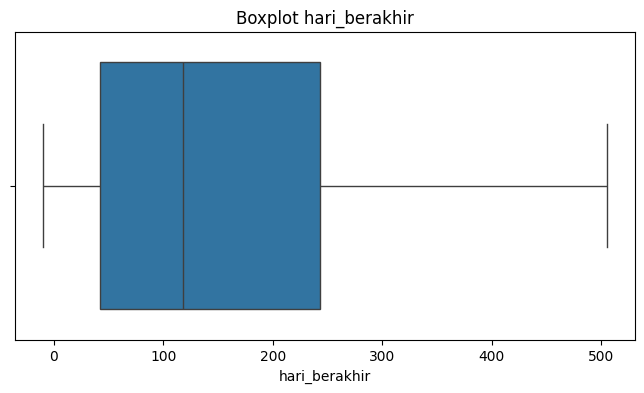

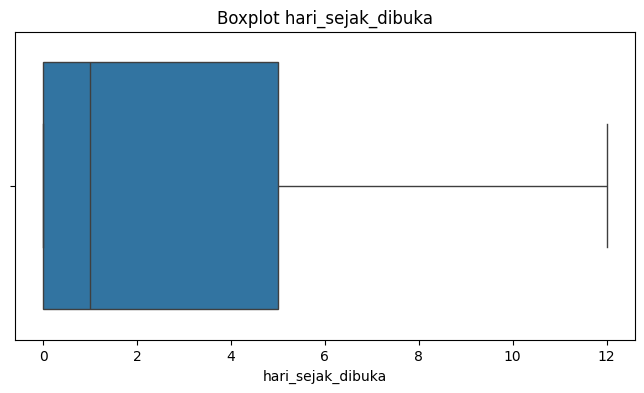

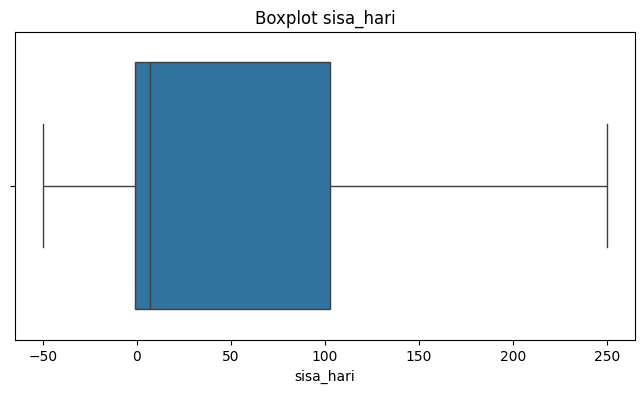

In [10]:
numerical_cols = [
    'hari_berakhir',
    'hari_sejak_dibuka',
    'sisa_hari'
]

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(x=df_clean[col])
    
    plt.title(f'Boxplot {col}')
    
    plt.show()

In [11]:
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]

    print(f'\nKolom: {col}')
    print(f'Jumlah outlier: {len(outliers)}')


Kolom: hari_berakhir
Jumlah outlier: 0

Kolom: hari_sejak_dibuka
Jumlah outlier: 0

Kolom: sisa_hari
Jumlah outlier: 0


In [12]:
for col in df_clean.columns:
    print(f"\nKolom: {col}")
    print(df_clean[col].unique())


Kolom: nama_makanan
['Yogurt Plain' 'Biskuit Marie' 'Nugget Udang' 'Sarden Cabai'
 'Biskuit Crackers' 'Susu Uht Stroberi' 'Sosis Frankfurter'
 'Biskuit Mentega' 'Susu Bubuk Coklat' 'Biskuit Wafer' 'Teh Lemon'
 'Nugget Ayam' 'Soda Jeruk' 'Sereal Cornflakes' 'Sarden Minyak Zaitun'
 'Susu Kental Manis Putih' 'Biskuit Oreo' 'Teh Kotak Hijau'
 'Sereal Coklat' 'Buah Cocktail' 'Yogurt Stroberi' 'Cola Zero Sugar'
 'Nugget Ikan' 'Nugget Tempe' 'Sosis Frozen' 'Biskuit Sandwich'
 'Leci Dalam Sirup' 'Nugget Sapi' 'Kornet Ayam' 'Sereal Oat'
 'Keju Mozzarella' 'Susu Uht Full Cream' 'Jus Sirsak' 'Mie Instan Ayam'
 'Sosis Ikan' 'Sereal Muesli' 'Susu Kental Manis Coklat' 'Sosis Sapi'
 'Keju Cream Cheese' 'Susu Uht Coklat' 'Air Mineral' 'Teh Tarik'
 'Susu Kedelai' 'Keju Cheddar' 'Sarden Tomat' 'Mie Instan Soto'
 'Jus Anggur' 'Susu Bubuk Skim' 'Yogurt Mangga' 'Ikan Salmon'
 'Nanas Kaleng' 'Ikan Tuna' 'Sosis Bebek' 'Cola Original'
 'Susu Uht Vanila' 'Yogurt Blueberry' 'Jus Mangga' 'Minuman Energi'
 'Minu

Pertanyaan 1: Bagaimana distribusi kategori makanan (food_category) dalam inventaris?


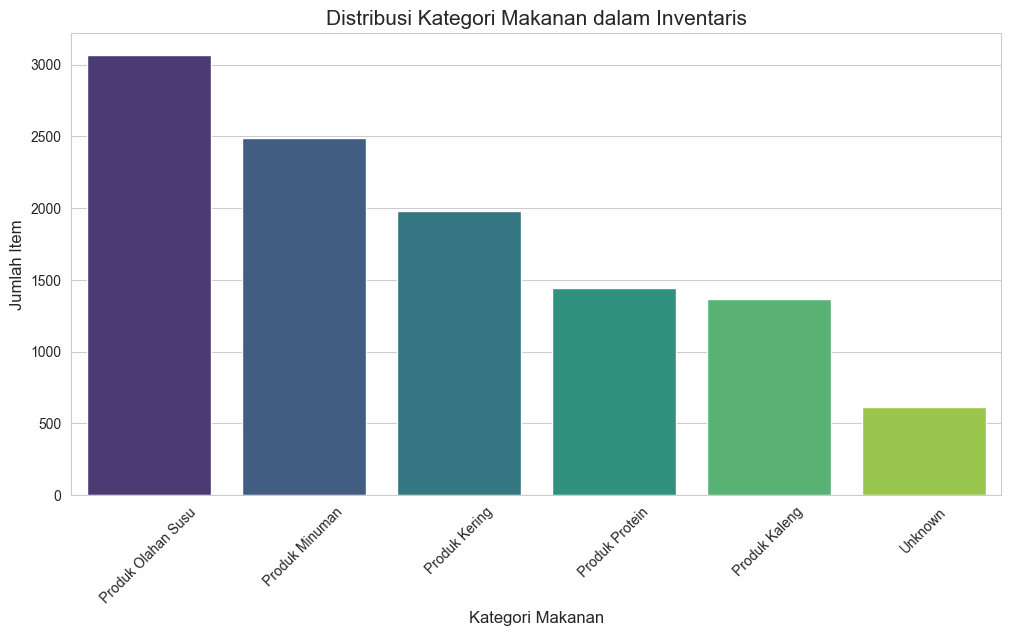

In [13]:
category_counts = df_clean['kategori_makanan'].value_counts()
category_percent = df_clean['kategori_makanan'].value_counts(normalize=True) * 100
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")

plt.title('Distribusi Kategori Makanan dalam Inventaris', fontsize=15)
plt.xlabel('Kategori Makanan', fontsize=12)
plt.ylabel('Jumlah Item', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [14]:
print("Top 5 Kategori Dominan")
print(category_counts.head(5))

print("\nPersentase Kontribusi")
print(category_percent.head(5).map('{:.2f}%'.format))

Top 5 Kategori Dominan
kategori_makanan
Produk Olahan Susu    3067
Produk Minuman        2485
Produk Kering         1979
Produk Protein        1442
Produk Kaleng         1364
Name: count, dtype: int64

Persentase Kontribusi
kategori_makanan
Produk Olahan Susu    28.00%
Produk Minuman        22.69%
Produk Kering         18.07%
Produk Protein        13.17%
Produk Kaleng         12.45%
Name: proportion, dtype: object


Pertanyaan 2: Apa jenis kemasan (packaging_type) yang paling sering digunakan?


In [15]:
packaging_counts = df_clean['jenis_kemasan'].value_counts()
packaging_percent = df_clean['jenis_kemasan'].value_counts(normalize=True) * 100

print("Ranking Jenis Kemasan:")
print(packaging_counts)

Ranking Jenis Kemasan:
jenis_kemasan
Plastik       4169
Karton        3298
Kaleng        2461
Unknown        502
Botol Kaca     433
Kardus          61
glass           13
Botol           11
Kaca             5
Name: count, dtype: int64


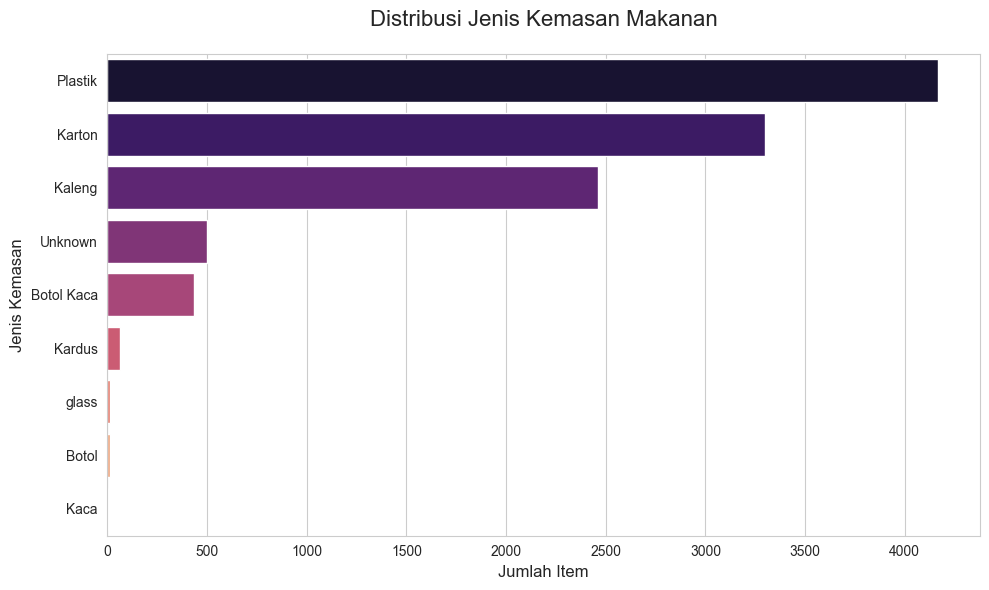

In [16]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_clean, 
    y='jenis_kemasan', 
    order=packaging_counts.index, 
    palette='magma'
)

plt.title('Distribusi Jenis Kemasan Makanan', fontsize=16, pad=20)
plt.xlabel('Jumlah Item', fontsize=12)
plt.ylabel('Jenis Kemasan', fontsize=12)

plt.tight_layout()
plt.show()

Pertanyaan 3: Bagaimana persebaran makanan berdasarkan lokasi penyimpanan (storage_location)? Apakah ada penumpukan di satu tempat tertentu (misal: kulkas vs pantry)?


In [17]:
mapping = {
    'frozen': 'Freezer',
    'Freeze': 'Freezer',
    'frzer': 'Freezer',
    'Dingin': 'Chiller',
    'Unknown': 'Other/Unknown'
}

df_clean['lokasi_penyimpanan'] = df_clean['lokasi_penyimpanan'].replace(mapping)
storage_dist = df_clean['lokasi_penyimpanan'].value_counts()
storage_percent = df_clean['lokasi_penyimpanan'].value_counts(normalize=True) * 100

print("Jumlah Item per Lokasi (Setelah Cleaning):")
print(storage_dist)

Jumlah Item per Lokasi (Setelah Cleaning):
lokasi_penyimpanan
Suhu Ruang       5191
Pendingin        4329
Pembeku           848
Other/Unknown     585
Name: count, dtype: int64


<Figure size 1600x800 with 0 Axes>

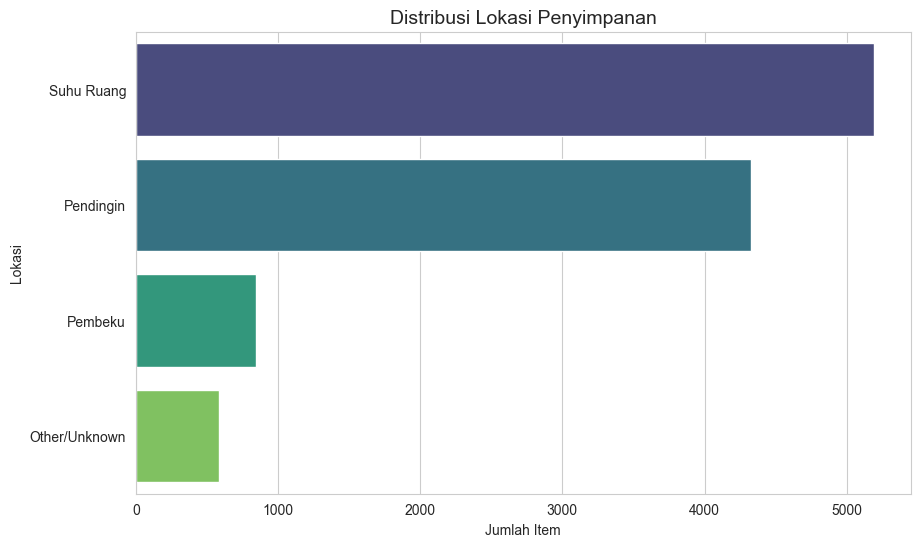

In [18]:
plt.figure(figsize=(16, 8))
colors = sns.color_palette('pastel')[0:len(storage_dist)]

plt.figure(figsize=(10, 6))
sns.barplot(x=storage_dist.values, y=storage_dist.index, palette='viridis')

plt.title('Distribusi Lokasi Penyimpanan', fontsize=14)
plt.xlabel('Jumlah Item')
plt.ylabel('Lokasi')
plt.show()

Pertanyaan 4: Berapa rata-rata sisa hari (sisa_hari) untuk setiap kategori makanan?


In [19]:
avg_sisa_hari = df_clean.groupby('kategori_makanan')['sisa_hari'].mean().sort_values()
print("Rata-rata Sisa Hari per Kategori (Urut dari yang paling mendesak):")
print(avg_sisa_hari)

Rata-rata Sisa Hari per Kategori (Urut dari yang paling mendesak):
kategori_makanan
Produk Protein        31.268377
Produk Olahan Susu    48.977502
Unknown               62.147727
Produk Minuman        67.477666
Produk Kering         71.090450
Produk Kaleng         79.659824
Name: sisa_hari, dtype: float64


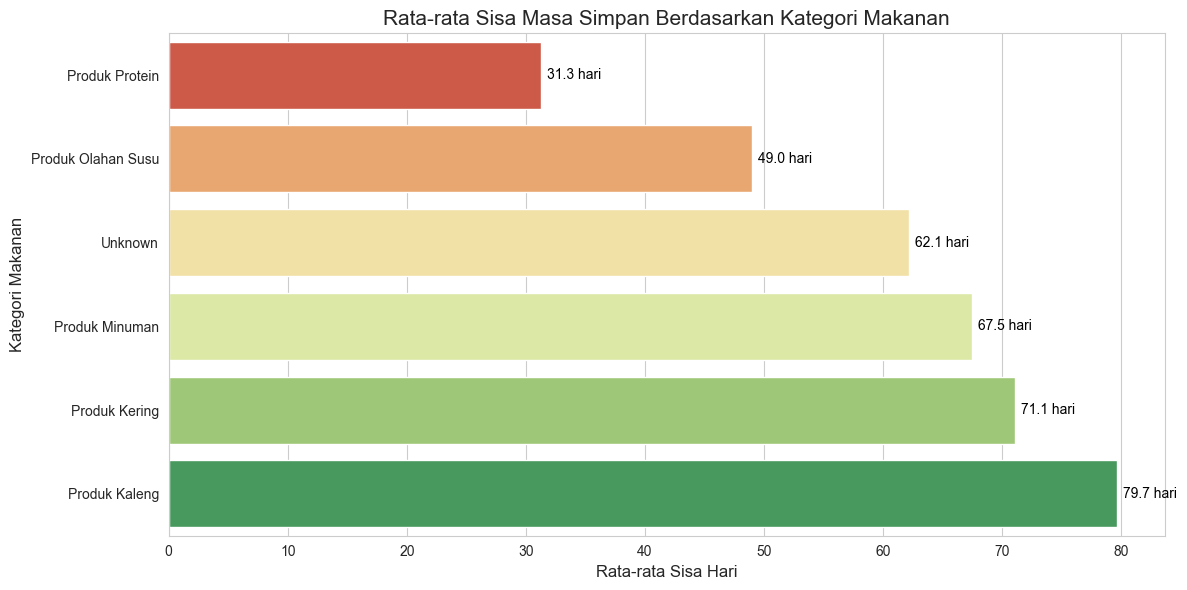

In [20]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(x=avg_sisa_hari.values, y=avg_sisa_hari.index, palette="RdYlGn")
for i, v in enumerate(avg_sisa_hari.values):
    ax.text(v + 0.5, i, f'{v:.1f} hari', color='black', va='center')

plt.title('Rata-rata Sisa Masa Simpan Berdasarkan Kategori Makanan', fontsize=15)
plt.xlabel('Rata-rata Sisa Hari', fontsize=12)
plt.ylabel('Kategori Makanan', fontsize=12)

plt.tight_layout()
plt.show()

Pertanyaan 5: Berapa persentase produk yang statusnya sudah "kritis" (misal: sisa_hari < 2 hari) dibandingkan total stok?


In [21]:
threshold_kritis = 2
jumlah_kritis = len(df_clean[df_clean['sisa_hari'] < threshold_kritis])
total_stok = len(df_clean)
persentase_kritis = (jumlah_kritis / total_stok) * 100
print(f"Total Stok: {total_stok} item")
print(f"Jumlah Stok Kritis (< {threshold_kritis} hari): {jumlah_kritis} item")
print(f"Persentase Stok Kritis: {persentase_kritis:.2f}%")

Total Stok: 10953 item
Jumlah Stok Kritis (< 2 hari): 4308 item
Persentase Stok Kritis: 39.33%


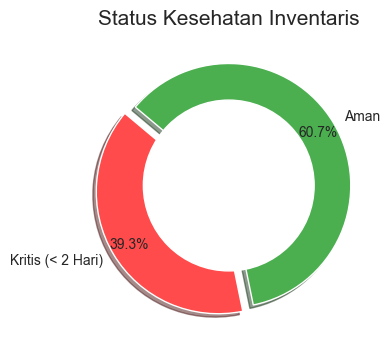

In [22]:
labels = ['Kritis (< 2 Hari)', 'Aman']
sizes = [jumlah_kritis, total_stok - jumlah_kritis]
colors = ['#ff4b4b', '#4baf50'] 
explode = (0.1, 0)

plt.figure(figsize=(4, 4))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', 
        shadow=True, startangle=140, pctdistance=0.85)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Status Kesehatan Inventaris', fontsize=15)
plt.tight_layout()
plt.show()

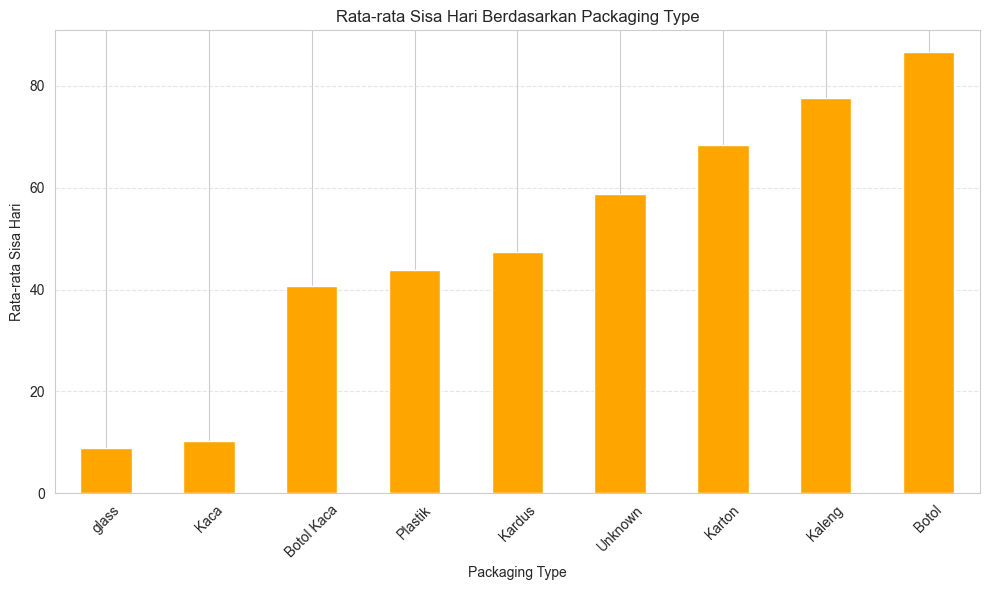

In [27]:
avg_sisa = (
    df_clean.groupby('jenis_kemasan')['sisa_hari']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

avg_sisa.plot(
    kind='bar',
    color='orange'
)

plt.title('Rata-rata Sisa Hari Berdasarkan Packaging Type')
plt.xlabel('Packaging Type')
plt.ylabel('Rata-rata Sisa Hari')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Pertanyaan 6: Berapa proporsi makanan yang sudah dibuka (is_opened) dibandingkan yang belum?


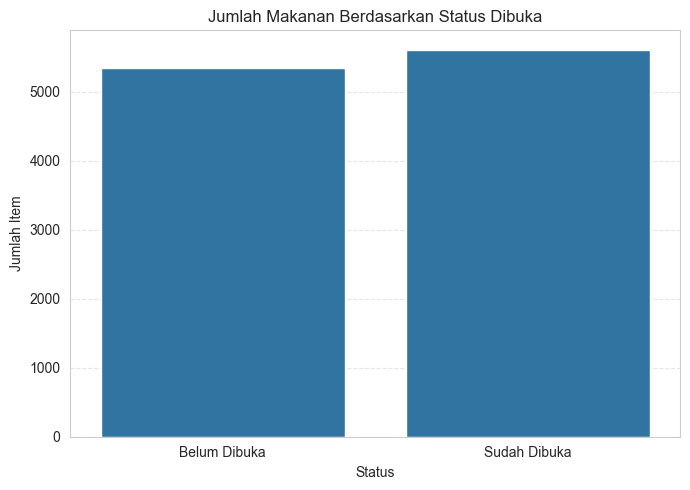

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x='sudah_terbuka'
)

plt.xticks([0, 1], ['Belum Dibuka', 'Sudah Dibuka'])

plt.title('Jumlah Makanan Berdasarkan Status Dibuka')
plt.xlabel('Status')
plt.ylabel('Jumlah Item')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Pertanyaan 7: Berapa rata-rata days_since_opened sebelum makanan akhirnya habis atau kadaluarsa?


Rata-rata hari_sejak_dibuka: 5.53 hari
Rata-rata lama setelah dibuka sebelum berisiko/expired: nan hari


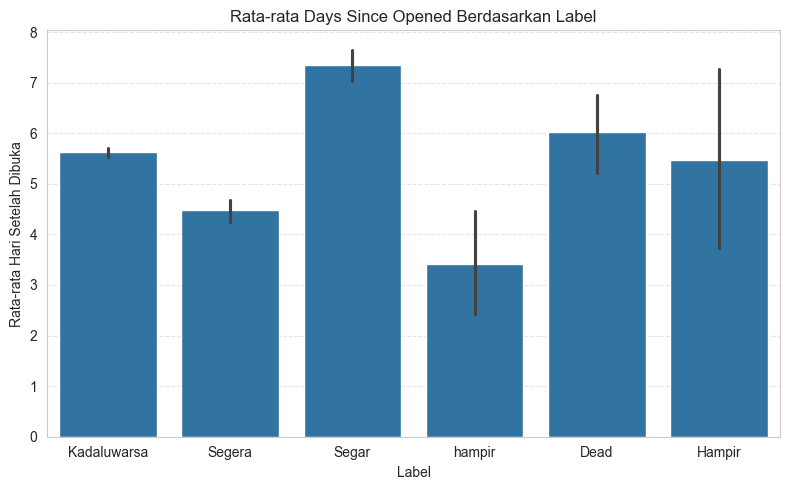

In [29]:
opened_food = df_clean[df_clean['sudah_terbuka'] == 1]

avg_days_opened = opened_food['hari_sejak_dibuka'].mean()

print(f"Rata-rata hari_sejak_dibuka: {avg_days_opened:.2f} hari")

risk_expired_food = opened_food[
    opened_food['label'].isin(['Expired', 'Risk'])
]

avg_days_risk = risk_expired_food['hari_sejak_dibuka'].mean()

print(
    f"Rata-rata lama setelah dibuka sebelum berisiko/expired: "
    f"{avg_days_risk:.2f} hari"
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=opened_food,
    x='label',
    y='hari_sejak_dibuka',
    estimator='mean'
)

plt.title('Rata-rata Days Since Opened Berdasarkan Label')
plt.xlabel('Label')
plt.ylabel('Rata-rata Hari Setelah Dibuka')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Pertanyaan 8: Apakah makanan yang sudah dibuka (is_opened = 1) memiliki penurunan sisa_hari yang lebih signifikan dibandingkan rata-rata kategori tersebut saat masih tertutup?


In [31]:
avg_sisa = (
    df_clean.groupby(['kategori_makanan', 'sudah_terbuka'])['sisa_hari']
    .mean()
    .reset_index()
)

avg_sisa['status'] = avg_sisa['sudah_terbuka'].map({
    0: 'Belum Dibuka',
    1: 'Sudah Dibuka'
})

print(avg_sisa.head())

  kategori_makanan  sudah_terbuka   sisa_hari        status
0    Produk Kaleng              0  189.784854  Belum Dibuka
1    Produk Kaleng              1   -2.054917  Sudah Dibuka
2    Produk Kering              0  131.034749  Belum Dibuka
3    Produk Kering              1    5.234358  Sudah Dibuka
4   Produk Minuman              0  132.793564  Belum Dibuka


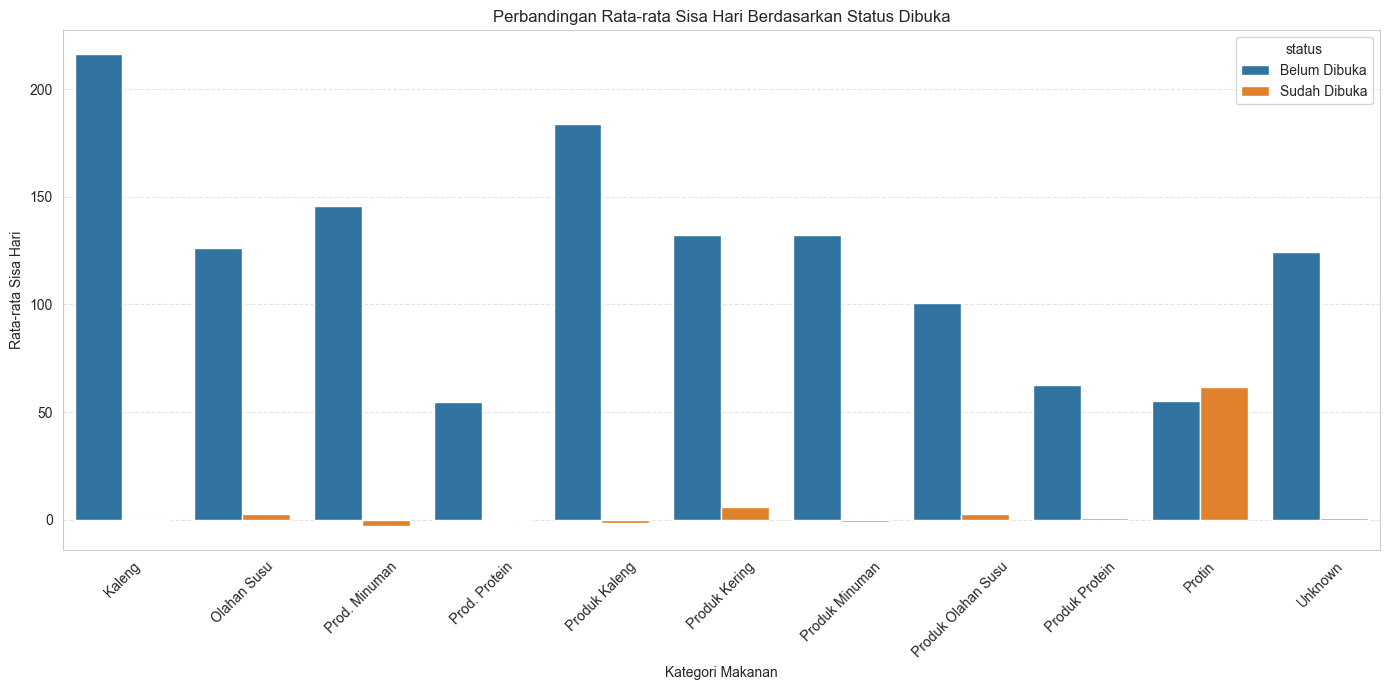

In [ ]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=avg_sisa,
    x='kategori_makanan',
    y='sisa_hari',
    hue='status'
)

plt.title('Perbandingan Rata-rata Sisa Hari Berdasarkan Status Dibuka')
plt.xlabel('Kategori Makanan')
plt.ylabel('Rata-rata Sisa Hari')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Pertanyaan 9: Lokasi penyimpanan (storage_location) mana yang paling efektif dalam menjaga makanan tetap awet (memiliki rata-rata sisa_hari tertinggi)?


  lokasi_penyimpanan  sisa_hari
0         Suhu Ruang  76.449624
1      Other/Unknown  61.270085
2          Pendingin  42.726496
3            Pembeku  38.863208


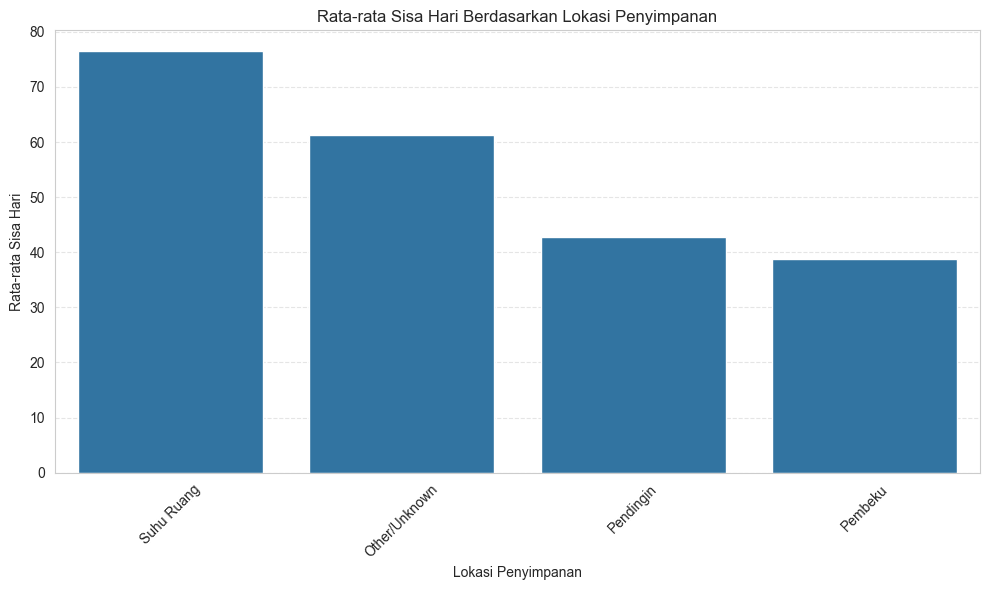

In [32]:
storage_avg = (
    df_clean.groupby('lokasi_penyimpanan')['sisa_hari']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print(storage_avg)

# Visualisasi
plt.figure(figsize=(10, 6))

sns.barplot(
    data=storage_avg,
    x='lokasi_penyimpanan',
    y='sisa_hari'
)

plt.title('Rata-rata Sisa Hari Berdasarkan Lokasi Penyimpanan')
plt.xlabel('Lokasi Penyimpanan')
plt.ylabel('Rata-rata Sisa Hari')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()